# fig1_new_region - Part 2/8\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


In [3]:
import numpy as np
import pandas as pd
import torch

# ================= triad motif 计数器（13 motifs）=================
class motifRegular:
    def __init__(self, numOfNeuron: int, device="cpu"):
        self.device = torch.device(device) if isinstance(device, str) else device
        n = numOfNeuron
        self.L = torch.ones((1, n), device=self.device)
        self.P = torch.ones((n, n), device=self.device)
        self.P.fill_diagonal_(0)

    def cal(self, a: torch.Tensor) -> torch.Tensor:
        w = (a > 0).to(a.dtype) * self.P
        pmw = self.P - w

        w0 = pmw * pmw.T
        w1 = w   * pmw.T
        w2 = pmw * w.T
        w3 = w   * w.T

        q = torch.zeros(14, dtype=torch.float32, device=self.device)

        q[1]  = 0.5 * self.L @ (w1 * (w1 @ w0)) @ self.L.T
        q[2]  = 0.5 * self.L @ (w0 * (w1 @ w2)) @ self.L.T
        q[3]  =       self.L @ (w1 * (w0 @ w2)) @ self.L.T
        q[4]  =       self.L @ (w1 * (w1 @ w2)) @ self.L.T

        q[5]  =       self.L @ (w3 * (w1 @ w0)) @ self.L.T
        q[6]  =       self.L @ (w3 * (w2 @ w0)) @ self.L.T
        q[7]  = 0.5 * self.L @ (w3 * (w1 @ w2)) @ self.L.T
        q[8]  = 0.5 * self.L @ (w3 * (w2 @ w1)) @ self.L.T

        q[9]  = 0.5 * self.L @ (w3 * (w3 @ w0)) @ self.L.T
        q[10] = (1.0/3.0) * self.L @ (w1 * (w2 @ w2)) @ self.L.T
        q[11] =       self.L @ (w3 * (w2 @ w2)) @ self.L.T
        q[12] =       self.L @ (w3 * (w3 @ w2)) @ self.L.T
        q[13] = (1.0/6.0) * self.L @ (w3 * (w3 @ w3)) @ self.L.T

        return q[1:14]  # (13,)

def c_n_3(n: int) -> int:
    return 0 if n < 3 else (n * (n - 1) * (n - 2)) // 6

def real_motif_for_submatrix(A, threshold=0.0, device="cpu"):
    A = np.asarray(A, dtype=float)
    np.fill_diagonal(A, 0.0)

    edge = (A > threshold)
    np.fill_diagonal(edge, False)

    n = A.shape[0]
    e = int(edge.sum())
    if n < 3 or e == 0:
        return None

    mr = motifRegular(n, device=device)
    real = mr.cal(torch.from_numpy(edge.astype(np.float32)).to(mr.device)).cpu().numpy()
    return {"real": real, "n": n, "e": e}

# ================= 主流程：按 clone 计算 + 汇总 =================
sc_path    = "wb_alltype_sc_subset_zj_1_2.5_42_1209.npy"
names_path = "wb_alltype_sc_subset_names_zj_1_2.5_42_1209.npy"
csv_path   = "Metadata_PFC_MOp.csv"

sc = np.load(sc_path)
names = np.load(names_path, allow_pickle=True)
names = names.tolist() if isinstance(names, np.ndarray) else list(names)
names = np.asarray([str(x) for x in names], dtype=str)

df = pd.read_csv(csv_path)

if "name" in df.columns:
    id_col = "name"
elif "Unnamed: 0" in df.columns:
    id_col = "Unnamed: 0"
else:
    raise ValueError("CSV 里找不到 neuron id 列（尝试 'name' / 'Unnamed: 0'），请手动指定 id_col。")

need_cols = {"clone", "Layer", "Clone_region"}
miss = need_cols - set(df.columns)
if miss:
    raise ValueError(f"CSV 缺少列: {miss}")

meta = df.set_index(id_col)
clone_arr = meta.reindex(names)["clone"].to_numpy()
layer_arr = meta.reindex(names)["Layer"].astype(str).to_numpy()
region_arr = meta.reindex(names)["Clone_region"].astype(str).to_numpy()

valid = ~pd.isna(clone_arr)
print(f"总节点数: {len(names)}")
print(f"按 clone 成功匹配到的节点数: {int(valid.sum())}")
print(f"共有 {pd.unique(clone_arr[valid]).size} 个 clone")

layer_order = ["2_3", "5", "6"]
motif_labels = [f"Motif {i+1}" for i in range(13)]

records = []
device = "cpu"
thr = 0.0   

for cl in pd.unique(clone_arr[valid]):
    idxs = np.flatnonzero((clone_arr == cl) & valid)
    if idxs.size < 3:
        continue

    A_sub = sc[np.ix_(idxs, idxs)]
    res = real_motif_for_submatrix(A_sub, threshold=thr, device=device)
    if res is None:
        continue

    n, e = res["n"], res["e"]
    sparsity = e / (n * (n - 1)) if n > 1 else np.nan


    row = {
        "clone": cl,
        "n": n,
        "e": e,
        "sparsity": sparsity,
        "c_n^3": c_n_3(n),
    }

    regs = region_arr[idxs]
    regs = regs[(regs != "nan") & (regs != "None") & (regs != "")]
    row["region"] = regs[0] if regs.size else ""

    # 13 motifs：只保留 real
    for k, m in enumerate(motif_labels):
        row[f"real_{m}"] = float(res["real"][k])

    # layer 内出入度（只算 clone 子图内部）
    A_bin = (A_sub > 0.0).astype(np.uint8)
    np.fill_diagonal(A_bin, 0)
    out_deg = A_bin.sum(1)
    in_deg  = A_bin.sum(0)

    layers = layer_arr[idxs]
    for L in layer_order:
        msk = (layers == L)
        nL = int(msk.sum())
        out_sum = int(out_deg[msk].sum()) if nL else 0
        in_sum  = int(in_deg[msk].sum())  if nL else 0
        out_mean = float(out_deg[msk].mean()) if nL else 0.0
        in_mean  = float(in_deg[msk].mean())  if nL else 0.0

        prefix = f"layer_{L}"
        row[f"{prefix}_n_nodes"]  = nL
        row[f"{prefix}_out_sum"]  = out_sum
        row[f"{prefix}_in_sum"]   = in_sum
        row[f"{prefix}_out_mean"] = out_mean
        row[f"{prefix}_in_mean"]  = in_mean

    records.append(row)
    print(f"完成 clone {cl} | n={n} e={e}")

all_stats_df = pd.DataFrame.from_records(records)
print("\n=== 总表预览（前几行） ===")
print(all_stats_df.head())

out_csv = "clone_motif_layer_all_in_one_2-5um_noZ_withCn3.csv"
all_stats_df.to_csv(out_csv, index=False)
print(f"\n已保存: {out_csv}")

总节点数: 751
按 clone 成功匹配到的节点数: 751
共有 92 个 clone
完成 clone ACA-062301-1 | n=8 e=8
完成 clone ACA-070301-2 | n=7 e=20
完成 clone ACA-071502-03 | n=9 e=39
完成 clone ACA-081201-1 | n=7 e=26
完成 clone ACA-230026-1 | n=7 e=4
完成 clone ACA-230031-1 | n=12 e=33
完成 clone ACA-233370-1 | n=10 e=12
完成 clone AI-220020-1 | n=9 e=10
完成 clone MOp-033001-1 | n=6 e=13
完成 clone MOp-061202-3 | n=8 e=24
完成 clone MOp-061202-5 | n=6 e=19
完成 clone MOp-062301-2 | n=7 e=15
完成 clone MOp-070301-1 | n=6 e=22
完成 clone MOp-091501-1 | n=6 e=10
完成 clone MOp-102602-3 | n=13 e=23
完成 clone MOp-102602-4 | n=7 e=12
完成 clone MOp-111404-3 | n=6 e=19
完成 clone MOp-120601-4 | n=6 e=13
完成 clone MOp-220022-1 | n=6 e=1
完成 clone MOp-220026-1 | n=6 e=7
完成 clone MOp-221015-1 | n=11 e=20
完成 clone MOp-221596-1 | n=7 e=16
完成 clone MOp-230030-1 | n=12 e=18
完成 clone MOp-232962-1 | n=8 e=7
完成 clone MOp-233369-2 | n=6 e=5
完成 clone MOp-233370-2 | n=6 e=3
完成 clone MOp-233372-1 | n=12 e=6
完成 clone MOp-233372-2 | n=6 e=6
完成 clone MOp-233373-2 | n=6 e=18

In [4]:
# ================= 6) 统计：PFC / MOp / MOs =================

# --- 1) 把 clone 的 region 映射到大类 ---
def map_region_to_group(r: str):
    if r is None:
        return np.nan
    r = str(r).strip()
    if r == "" or r.lower() == "nan":
        return np.nan

    # PFC: ACA, PL, FRP, ORB（常见还有 ACAd/ACAv/ORBl/ORBvl/ORBm...）
    if r.startswith(("ACA", "PL", "FRP", "ORB")):
        return "PFC"
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return np.nan

all_stats_df["group"] = all_stats_df["region"].map(map_region_to_group)

# 只保留这三组
df3 = all_stats_df[all_stats_df["group"].isin(["PFC", "MOp", "MOs"])].copy()

# --- 2) 计算 real_motif / cn3（每个 clone 一行）---
motif_cols = [f"real_Motif {i+1}" for i in range(13)]
for c in motif_cols:
    df3[f"{c}_per_cn3"] = df3[c] / df3["c_n^3"].replace(0, np.nan)

# --- 3) 每组：real_motif/cn3 的均值 & 方差 ---
# 方差用 sample var (ddof=1)
ratio_cols = [f"{c}_per_cn3" for c in motif_cols]
motif_stats = (
    df3.groupby("group")[ratio_cols]
       .agg(["mean", lambda x: x.var(ddof=1)])
)

# 把 var 的列名弄好看点
motif_stats.columns = [f"{a}_{b if b!='<lambda>' else 'var'}" for a, b in motif_stats.columns]
print("\n=== 各组 real_motif/cn3 的均值/方差（每个 motif） ===")
print(motif_stats)

# --- 4) 每组：layer 平均出入度（out_mean/in_mean）的均值 & 方差 ---
layer_order = ["2_3", "5", "6"]
deg_cols = []
for L in layer_order:
    deg_cols += [f"layer_{L}_out_mean", f"layer_{L}_in_mean"]

deg_stats = (
    df3.groupby("group")[deg_cols]
       .agg(["mean", lambda x: x.var(ddof=1)])
)
deg_stats.columns = [f"{a}_{b if b!='<lambda>' else 'var'}" for a, b in deg_stats.columns]
print("\n=== 各组 layer 平均出入度(out_mean/in_mean) 的均值/方差 ===")
print(deg_stats)

# --- 5) 可选：把统计结果存成 csv ---
motif_stats.to_csv("group_stats_motif_per_cn3_mean_var.csv")
deg_stats.to_csv("group_stats_layer_deg_mean_var.csv")
print("\n已保存: group_stats_motif_per_cn3_mean_var.csv")
print("已保存: group_stats_layer_deg_mean_var.csv")


=== 各组 real_motif/cn3 的均值/方差（每个 motif） ===
       real_Motif 1_per_cn3_mean  real_Motif 1_per_cn3_<lambda_0>  \
group                                                               
MOp                     0.047234                         0.002312   
MOs                     0.051408                         0.003307   
PFC                     0.032286                         0.001345   

       real_Motif 2_per_cn3_mean  real_Motif 2_per_cn3_<lambda_0>  \
group                                                               
MOp                     0.036254                         0.001354   
MOs                     0.033567                         0.001936   
PFC                     0.022718                         0.000861   

       real_Motif 3_per_cn3_mean  real_Motif 3_per_cn3_<lambda_0>  \
group                                                               
MOp                     0.059184                         0.003216   
MOs                     0.061168                         

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# ===== 1) region -> group 映射（PFC=ACA/PL/FRP/ORB，MOp/MOs同理）=====
def map_region_to_group(r):
    r = str(r).strip()
    if r == "" or r.lower() == "nan":
        return np.nan
    if r.startswith(("ACA", "PL", "FRP", "ORB")):
        return "PFC"
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return np.nan

all_stats_df["group"] = all_stats_df["region"].map(map_region_to_group)
df3 = all_stats_df[all_stats_df["group"].isin(["PFC", "MOp", "MOs"])].copy()

# ===== 2) 准备每个 clone 的 motif 指标：real 或 real/cn3 =====
motif_cols = [f"real_Motif {i+1}" for i in range(13)]
use_ratio = True  # True: real/cn3; False: 用原始 real 计数

if use_ratio:
    denom = df3["c_n^3"].replace(0, np.nan)
    for c in motif_cols:
        df3[c] = df3[c] / denom  # 直接覆盖成 per_cn3

# ===== 3) BH-FDR（不额外引包）=====
def bh_fdr(pvals):
    pvals = np.asarray(pvals, float)
    m = pvals.size
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = np.clip(q, 0, 1)
    return out

# ===== 4) 每个 motif 在三组之间做 t-test（两两比较）=====
pairs = [("PFC", "MOp"), ("PFC", "MOs"), ("MOp", "MOs")]
records = []

for mcol in motif_cols:
    for g1, g2 in pairs:
        x = df3.loc[df3["group"] == g1, mcol].astype(float).to_numpy()
        y = df3.loc[df3["group"] == g2, mcol].astype(float).to_numpy()

        # 去掉 nan
        x = x[np.isfinite(x)]
        y = y[np.isfinite(y)]

        if x.size < 2 or y.size < 2:
            t, p = np.nan, np.nan
        else:
            t, p = ttest_ind(x, y, equal_var=False)  # Welch t-test

        records.append({
            "motif": mcol.replace("real_", ""),   # Motif 1..13
            "comparison": f"{g1} vs {g2}",
            "n1": int(x.size),
            "n2": int(y.size),
            "mean1": float(np.mean(x)) if x.size else np.nan,
            "mean2": float(np.mean(y)) if y.size else np.nan,
            "t": float(t) if np.isfinite(t) else np.nan,
            "p": float(p) if np.isfinite(p) else np.nan,
        })

tt_df = pd.DataFrame(records)
tt_df["p_fdr"] = bh_fdr(tt_df["p"].to_numpy())

print(tt_df.sort_values(["motif", "comparison"]).head(15))
tt_df.to_csv("ttest_motif_PFC_MOp_MOs.csv", index=False)
print("已保存: ttest_motif_PFC_MOp_MOs.csv")

       motif  comparison  n1  n2     mean1     mean2         t         p  \
2    Motif 1  MOp vs MOs  41  33  0.047234  0.051408 -0.333576  0.739819   
0    Motif 1  PFC vs MOp  17  41  0.032286  0.047234 -1.283980  0.206725   
1    Motif 1  PFC vs MOs  17  33  0.032286  0.051408 -1.427797  0.160162   
29  Motif 10  MOp vs MOs  41  33  0.002169  0.002623 -0.252574  0.801322   
27  Motif 10  PFC vs MOp  17  41  0.001948  0.002169 -0.104279  0.917536   
28  Motif 10  PFC vs MOs  17  33  0.001948  0.002623 -0.321717  0.749670   
32  Motif 11  MOp vs MOs  41  33  0.016765  0.024908 -0.902546  0.371156   
30  Motif 11  PFC vs MOp  17  41  0.027177  0.016765  0.894036  0.381435   
31  Motif 11  PFC vs MOs  17  33  0.027177  0.024908  0.168474  0.867235   
35  Motif 12  MOp vs MOs  41  33  0.041555  0.095278 -1.918854  0.061900   
33  Motif 12  PFC vs MOp  17  41  0.071626  0.041555  1.131358  0.270324   
34  Motif 12  PFC vs MOs  17  33  0.071626  0.095278 -0.659193  0.513186   
38  Motif 13

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


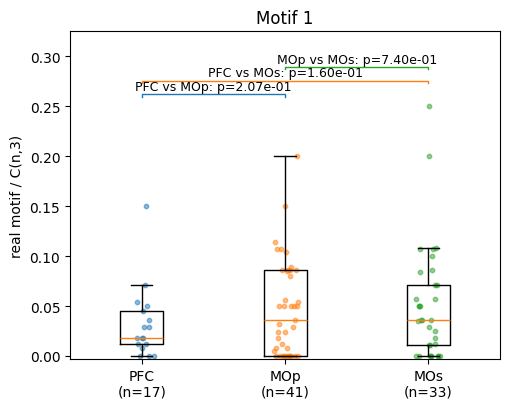

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


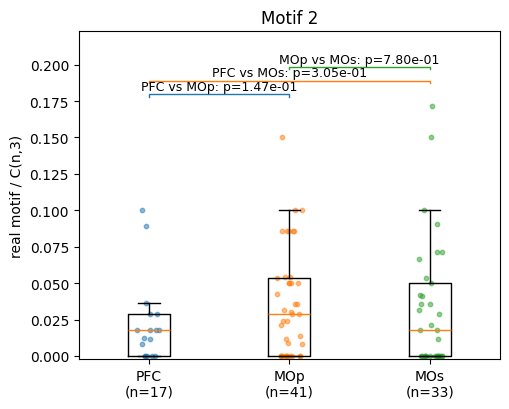

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


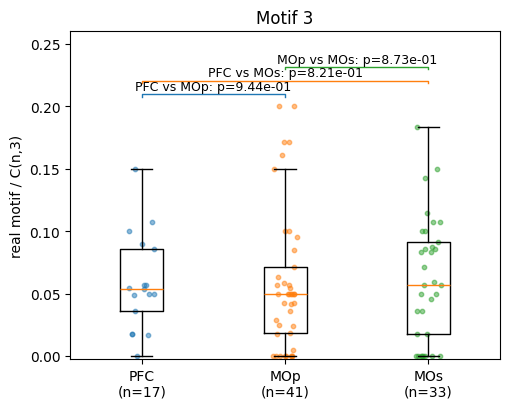

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


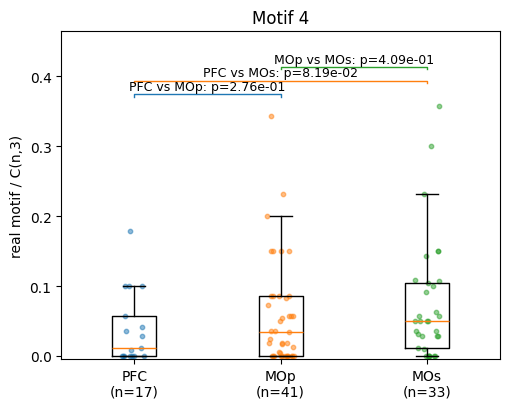

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


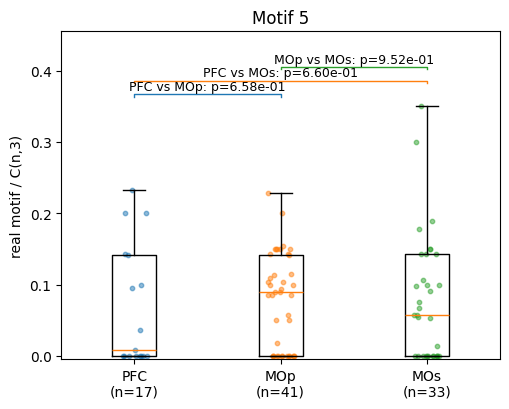

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


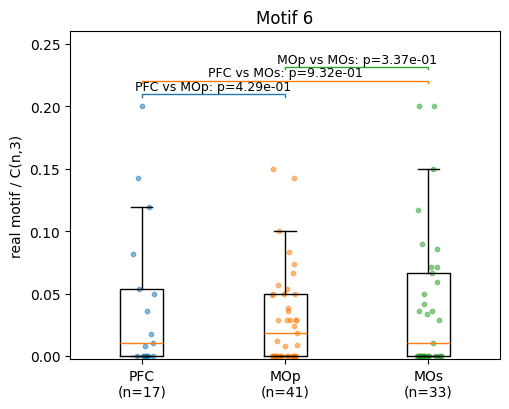

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


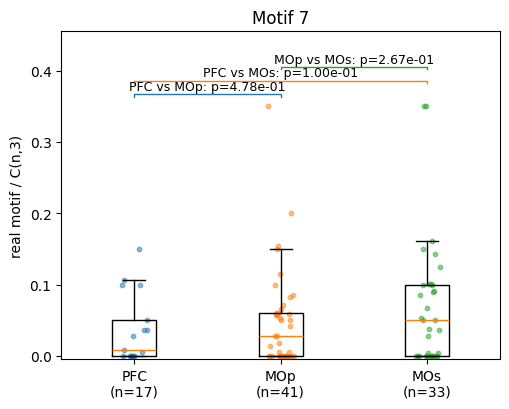

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


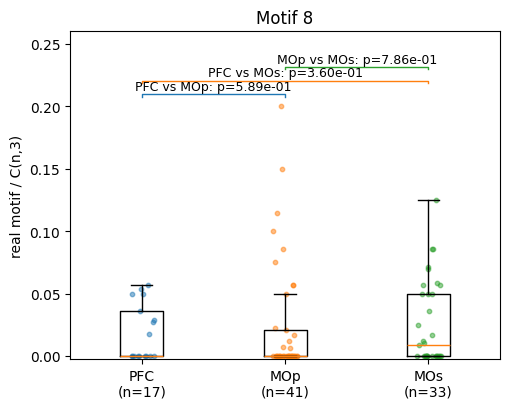

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


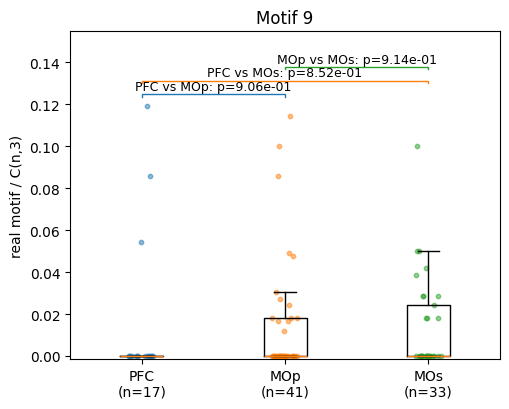

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


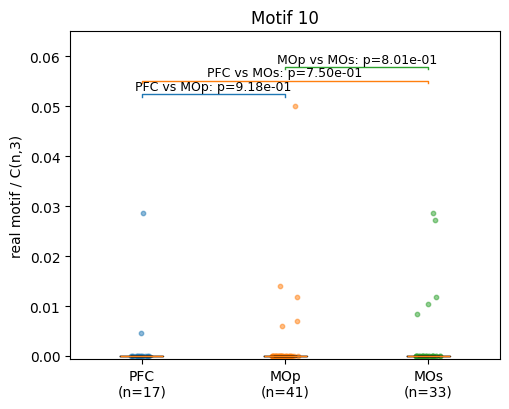

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


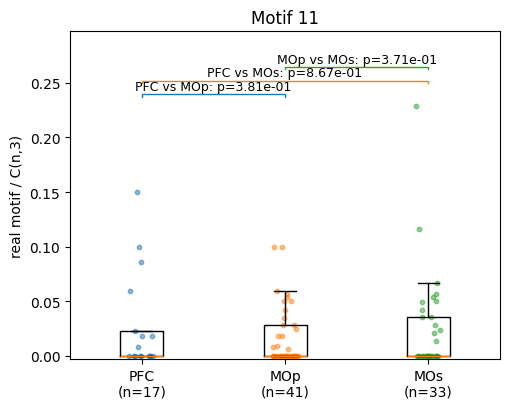

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


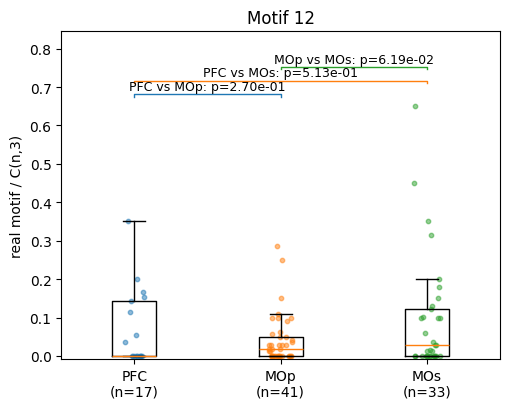

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_69697/587868688.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)


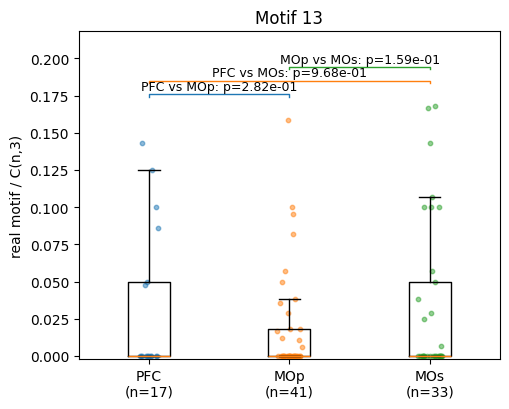

完成：已保存 motif_01~motif_13 的箱线图 PNG（带 t-test p 值）。


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ===== 0) 读数据（如果你内存里已经有 all_stats_df，可注释这两行）=====
# all_stats_df = pd.read_csv("clone_motif_layer_all_in_one_2-5um_noZ_withCn3.csv")

# ===== 1) region -> group（PFC=ACA/PL/FRP/ORB；MOp/MOs）=====
def map_region_to_group(r):
    r = str(r).strip()
    if r == "" or r.lower() == "nan":
        return np.nan
    if r.startswith(("ACA", "PL", "FRP", "ORB")):
        return "PFC"
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return np.nan

df3 = all_stats_df.copy()
df3["group"] = df3["region"].map(map_region_to_group)
df3 = df3[df3["group"].isin(["PFC", "MOp", "MOs"])].copy()

groups = ["PFC", "MOp", "MOs"]

# ===== 2) 选择指标：real 或 real/cn3 =====
use_ratio = True  # True: real/cn3；False: 原始 real
motif_cols = [f"real_Motif {i+1}" for i in range(13)]

if use_ratio:
    denom = df3["c_n^3"].replace(0, np.nan)
    for c in motif_cols:
        df3[c] = df3[c] / denom

ylab = "real motif / C(n,3)" if use_ratio else "real motif count"

# ===== 3) 画 13 张图 + t-test 标注 =====
pairs = [(0, 1, "PFC vs MOp"), (0, 2, "PFC vs MOs"), (1, 2, "MOp vs MOs")]

for i in range(13):
    col = f"real_Motif {i+1}"

    data = [df3.loc[df3["group"] == g, col].astype(float).dropna().to_numpy() for g in groups]
    ns = [len(x) for x in data]

    fig, ax = plt.subplots(figsize=(5.2, 4.2))

    # 箱线图
    ax.boxplot(data, labels=[f"{g}\n(n={n})" for g, n in zip(groups, ns)], showfliers=False)

    # 叠加散点（jitter）
    for xi, y in enumerate(data, start=1):
        if len(y) == 0:
            continue
        jitter = (np.random.rand(len(y)) - 0.5) * 0.18
        ax.scatter(np.full_like(y, xi, dtype=float) + jitter, y, s=10, alpha=0.5)

    ax.set_title(f"Motif {i+1}")
    ax.set_ylabel(ylab)

    # 计算 t-test（Welch）
    pvals = []
    for a, b, _ in pairs:
        x, y = data[a], data[b]
        if len(x) < 2 or len(y) < 2:
            p = np.nan
        else:
            p = ttest_ind(x, y, equal_var=False).pvalue
        pvals.append(p)

    # y 轴上方留白
    y_all = np.concatenate([x for x in data if len(x) > 0]) if any(len(x) for x in data) else np.array([0.0])
    y_min, y_max = float(np.min(y_all)), float(np.max(y_all))
    pad = (y_max - y_min) * 0.25 if y_max > y_min else 1.0
    ax.set_ylim(y_min - 0.05 * pad, y_max + 1.2 * pad)

    # 标注显著性括号 + p 值
    base = y_max + 0.15 * pad
    step = 0.22 * pad

    for k, (a, b, label) in enumerate(pairs):
        p = pvals[k]
        y = base + k * step
        x1, x2 = a + 1, b + 1
        ax.plot([x1, x1, x2, x2], [y, y + 0.04 * pad, y + 0.04 * pad, y], lw=1)

        if np.isnan(p):
            txt = f"{label}: p=NA"
        else:
            txt = f"{label}: p={p:.2e}"
        ax.text((x1 + x2) / 2, y + 0.06 * pad, txt, ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    fig.savefig(f"motif_{i+1:02d}_box_ttest.png", dpi=300)
    plt.show()

print("完成：已保存 motif_01~motif_13 的箱线图 PNG（带 t-test p 值）。")

In [3]:
import numpy as np
import pandas as pd
import math
import torch
from tqdm import tqdm

# ================= motifRegular 和 ER 随机采样 =================


class motifRegular:
    def __init__(self, device="cpu", numOfNeuron=512, amplitude=1000, bias=0.05):
        if isinstance(device, str):
            device = torch.device(device)
        
        self.L = torch.ones([1, numOfNeuron]).to(device)
        self.I = torch.zeros([numOfNeuron, numOfNeuron]).to(device)
        self.P = torch.zeros([numOfNeuron, numOfNeuron]).to(device)
        self.obs = torch.zeros([14]).to(device)
        self.sum = combination(numOfNeuron, 3)
        self.recordSum = 0
        self.amplitude = amplitude
        self.bias = bias
        self.device = device

        for i in range(numOfNeuron):
            self.I[i][i] = 1
        for i in range(numOfNeuron):
            for j in range(numOfNeuron):
                if i == j:
                    continue
                self.P[i][j] = 1

    def cal(self, a):
        w = torch.where(a > 0.0, torch.ones_like(a), torch.zeros_like(a))
        w = w * self.P
        pmw = self.P - w

        w0 = pmw * pmw.T
        w1 = w   * pmw.T
        w2 = pmw * w.T
        w3 = w   * w.T

        q = torch.zeros([14], dtype=torch.float32, device=self.device)

        q[1]  = 0.5 * self.L @ (w1 * (w1 @ w0)) @ self.L.T
        q[2]  = 0.5 * self.L @ (w0 * (w1 @ w2)) @ self.L.T
        q[3]  =       self.L @ (w1 * (w0 @ w2)) @ self.L.T
        q[4]  =       self.L @ (w1 * (w1 @ w2)) @ self.L.T

        q[5]  =       self.L @ (w3 * (w1 @ w0)) @ self.L.T
        q[6]  =       self.L @ (w3 * (w2 @ w0)) @ self.L.T
        q[7]  = 0.5 * self.L @ (w3 * (w1 @ w2)) @ self.L.T
        q[8]  = 0.5 * self.L @ (w3 * (w2 @ w1)) @ self.L.T

        q[9]  = 0.5 * self.L @ (w3 * (w3 @ w0)) @ self.L.T
        q[10] = (1.0/3.0) * self.L @ (w1 * (w2 @ w2)) @ self.L.T
        q[11] =       self.L @ (w3 * (w2 @ w2)) @ self.L.T
        q[12] =       self.L @ (w3 * (w3 @ w2)) @ self.L.T
        q[13] = (1.0/6.0) * self.L @ (w3 * (w3 @ w3)) @ self.L.T

        return q[1:14]


def sample_random_counts(n, e, n_rand, seed=None, device="cpu"):
    rng = np.random.default_rng(seed)
    samples = np.zeros((n_rand, 13), dtype=float)

    mask = np.ones((n, n), dtype=bool)
    np.fill_diagonal(mask, False)
    offdiag_idx = np.flatnonzero(mask)

    A = np.zeros((n, n), dtype=np.float32)
    mr = motifRegular(device=device, numOfNeuron=n)

    for r in tqdm(range(n_rand), desc="Sampling ER", leave=False):
        A.fill(0.0)
        chosen = rng.choice(offdiag_idx, size=e, replace=False)
        A.flat[chosen] = 1.0

        q = mr.cal(torch.from_numpy(A).to(device=device))
        samples[r] = q.cpu().numpy()

    return samples


def analyze_motif_for_submatrix(A, n_rand=2000, threshold=0.0, seed=0, device="cpu"):
    A = np.asarray(A, dtype=float)
    np.fill_diagonal(A, 0.0)

    edge_mask = A > threshold
    np.fill_diagonal(edge_mask, False)

    n = A.shape[0]
    e = int(edge_mask.sum())

    if n < 3 or e == 0:
        return None

    w_real = edge_mask.astype(np.float32)
    mr_real = motifRegular(device=device, numOfNeuron=n)
    real = mr_real.cal(torch.from_numpy(w_real).to(device=device)).cpu().numpy()

    samples = sample_random_counts(n, e, n_rand=n_rand, seed=seed, device=device)
    mu = samples.mean(axis=0)
    sd = samples.std(axis=0, ddof=1)

    z = np.zeros_like(real)
    valid = sd > 1e-8
    z[valid] = (real[valid] - mu[valid]) / sd[valid]
    nz = np.zeros_like(real) 
    nz = z / np.linalg.norm(z)
    idx = [f"Motif {i+1}" for i in range(13)]
    df = pd.DataFrame(
        {"real": real, "ER mean": mu, "ER sd": sd, "Z_ER": z,"NZ_ER": nz},
        index=idx
    )

    return {
        "table": df,
        "real": real,
        "er_mu": mu,
        "er_sd": sd,
        "z": z,
        "n": n,
        "e": e,
    }


# ================== 只算“总的 MOp 网络” ==================

sc_path    = "wb_alltype_sc_subset_zj_1_5_42_1209.npy"
names_path = "wb_alltype_sc_subset_names_zj_1_5_42_1209.npy"
csv_path   = "Metadata_PFC_MOp.csv"

sc = np.load(sc_path)
names = np.load(names_path, allow_pickle=True)
if isinstance(names, np.ndarray):
    names = names.tolist()

df = pd.read_csv(csv_path)

# ---- neuron id 列 ----
if "name" in df.columns:
    neuron_id_col = "name"
elif "Unnamed: 0" in df.columns:
    neuron_id_col = "Unnamed: 0"
else:
    raise ValueError("CSV 里找不到和 names 对应的列（尝试 'name' / 'Unnamed: 0'）")

# ---- region 列（尽量自动兼容）----
region_col = None
for cand in ["soma_region", "region", "Region", "area"]:
    if cand in df.columns:
        region_col = cand
        break
if region_col is None:
    raise ValueError(
        "CSV 里找不到脑区列（尝试 soma_region/region/Region/area）。"
        "请手动把 region_col 改成你的列名。"
    )

# ---- 判定 MOp（兼容 MOp, MOp1, MOp2/3 等）----
def is_mop(x):
    if x is None:
        return False
    s = str(x)
    return s == "MOp" or s.startswith("MOp")

df_mop = df[df[region_col].apply(is_mop)].copy()
print("用于 MOp 的 metadata 行数:", len(df_mop))

# ---- MOp neuron ID 集合 ----
mop_id_set = set(df_mop[neuron_id_col].astype(str).tolist())

# ---- 在 names 里找对应 index ----
mop_indices = []
for i, nid in enumerate(names):
    if str(nid) in mop_id_set:
        mop_indices.append(i)

print("总节点数:", len(names))
print("MOp 匹配到的节点数:", len(mop_indices))

if len(mop_indices) < 3:
    raise ValueError("MOp 节点不足 3 个，无法计算 triad motifs")

# ---- MOp 总网络子矩阵 ----
A_sub = sc[np.ix_(mop_indices, mop_indices)]
print("MOp 子矩阵形状:", A_sub.shape)

# ---- 计算 NZ ----
res = analyze_motif_for_submatrix(
    A_sub,
    n_rand=2000,     # 你原来就是 2000
    threshold=0.0,
    seed=42,
    device="cpu"
)

if res is None:
    raise ValueError("MOp 总网络没有边或不满足 triad 计算条件")

print("\n================= MOp (ALL clones merged) =================")
print(f"n = {res['n']}, e = {res['e']}, sparsity = {res['e'] / (res['n']*(res['n']-1)):.6f}")

print("\n--- NZ-score (NZ_ER) 13维 ---")
print(res["z"])

print("\n--- Table ---")
print(res["table"])

# ---- 保存一个表（可选）----
res["table"].to_csv("MOp_ALL_clones_NZ_ER_5um.csv")
print("\n✅ Saved:",
      "MOp_ALL_clones_NZ_ER_5um.csv")

用于 MOp 的 metadata 行数: 225
总节点数: 751
MOp 匹配到的节点数: 225
MOp 子矩阵形状: (225, 225)



================= MOp (ALL clones merged) =================
n = 225, e = 2387, sparsity = 0.047361

--- NZ-score (NZ_ER) 13维 ---
[ -22.967299  -41.821945  -45.92724    30.481195   32.182903   14.790398
  175.88084   154.45468    62.519123  -10.125633   49.543842  461.12698
 1790.4927  ]

--- Table ---
                 real       ER mean       ER sd         Z_ER     NZ_ER
Motif 1   6673.000000  10380.436500  161.422401   -22.967299 -0.012301
Motif 2   3735.000000  10378.347000  158.848355   -41.821945 -0.022399
Motif 3   7603.000000  20751.387500  286.287353   -45.927238 -0.024597
Motif 4   2169.000000   1030.644000   37.346173    30.481195  0.016325
Motif 5   5225.000000   1032.087000  130.283861    32.182903  0.017236
Motif 6   2923.000000   1031.477000  127.888581    14.790398  0.007921
Motif 7   1047.000000     25.826500    5.806053   175.880844  0.094196
Motif 8    928.000000     25.639000    5.842238   154.454681  0.082721
Motif 9    544.000000     25.682000    8.290551    62.519

In [9]:
import pickle, numpy as np
d = pickle.load(open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl","rb"))
real_motif = np.asarray(d["results"][5]["MOp"]["motif_results"]["0"]["real_motif"], float)
print(real_motif, real_motif.shape)
real_motif_clone = res["table"]["real"].values
print(real_motif_clone, real_motif_clone.shape)
frequency = real_motif / real_motif.sum()
frequency_clone = real_motif_clone / real_motif_clone.sum()
print("Frequency (all MOp):", frequency)
print("Frequency (MOp clones):", frequency_clone)

[587586. 383596. 596557. 195870. 383142. 226420.  76434.  72395.  43972.
  13947.  47165.  65665.  18916.] (13,)
[6673.      3735.      7603.      2169.      5225.      2923.
 1047.       928.       544.       143.00003  523.       786.
  251.     ] (13,)
Frequency (all MOp): [0.21668827 0.14146143 0.21999657 0.07223237 0.141294   0.08349851
 0.02818711 0.02669762 0.01621587 0.00514333 0.01739337 0.02421575
 0.00697579]
Frequency (MOp clones): [0.20500769 0.11474654 0.23357911 0.06663594 0.16052227 0.08980031
 0.0321659  0.02850998 0.01671275 0.00439324 0.01606759 0.02414747
 0.00771121]


In [45]:
import pickle
import pandas as pd

pkl_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
d = pickle.load(open(pkl_path, "rb"))

rows = []
for region in d["results"][5].keys():  # 5um
    item = d["results"][5][region]["motif_results"]["0.1"]  # 强度阈值=0.1（按你指定的访问方式）
    rows.append({
        "region": region,
        "node": item["node"],    # 节点数
        "edges": item["edges"],  # 边数
    })

df = pd.DataFrame(rows).sort_values("edges", ascending=False).reset_index(drop=True)
df.to_csv("nodes_edges_by_region_5um_thr0.1.csv", index=False, encoding="utf-8-sig")

print("已保存: nodes_edges_by_region_5um_thr0.1.csv")
print(df.head(20).to_string(index=False))

已保存: nodes_edges_by_region_5um_thr0.1.csv
 region  node  edges
    CA1  4396 296256
    CA3  1066 148625
    MOs  2261 142019
SSp-bfd  1187  66885
    ENT  1014  44393
    PIR   879  43490
   RSPv   781  43009
    MOp   957  39569
     DG  3307  38194
   ACAd  1225  35823
   AUDp   541  35268
    SSs   909  34262
   VISp  1059  28691
    SUB   928  27397
    AId  1166  25435
   VISa   624  23200
  SSp-m   591  20288
     PL  1384  18967
    TEa   444  14471
   ProS   677  14234


In [ ]:
er_motif,er_motif_sd = d["results"][5]["MOp"]["motif_results"]["0"]['er_mu_mc'],d["results"][5]["MOp"]["motif_results"]["0"]['er_sd_mc']
er_motif_clone,er_motif_sd_clone = res["table"]["ER mean"].values,res["table"]["ER sd"].values
